# Introduction to Focus Areas – Assignment 2

### Gwendolyn Howes and Eric Germersdorf

## Exercise 1: Regression and Early Stopping in Py-Torch

In this exercise, you will train a neural network for a regression task using **Py-Torch**. You will learn how to prepare data, implement a regression model, evaluate it using multiple metrics, and apply early stopping to prevent overfit-ting.

You will use the QSAR Fish Toxicity dataset, a well-established benchmark in computational toxicology for predicting the toxicity of chemical compounds to fish. Each entry in the dataset represents one compound, described by a small set of calculated molecular descriptors that capture physical and chemical properties (e.g., hydrophobicity, electronic distribution, and molecular structure)

The goal is to predict the acute aquatic toxicity value, expressed as LC50 in negative logarithmic form (-log mol/L), which indicates the concentration of a compound that causes 50% lethality in fish. A higher (-log mol/L) value corresponds to a more toxic compound.

### Step 1: Load the dataset

Download QSAR Fish Toxicity dataset as in:

`from sklearn.datasets import fetch_openml`

`data = fetch_openml(name="qsar_fish_toxicity", version=7, as_frame=True)`

`X = data.data`

`y = data.target.astype(float)`

In [36]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="qsar_fish_toxicity", version=7, as_frame=True)
X = data.data
y = data.target.astype(float)

Print the shape of X and a few summary statistics of y (mean, standard deviation, min, max).

shape: (908, 6)
mean: 4.064430616740088
standard deviation: 1.4548966290197731
min: 0.053
max: 9.612


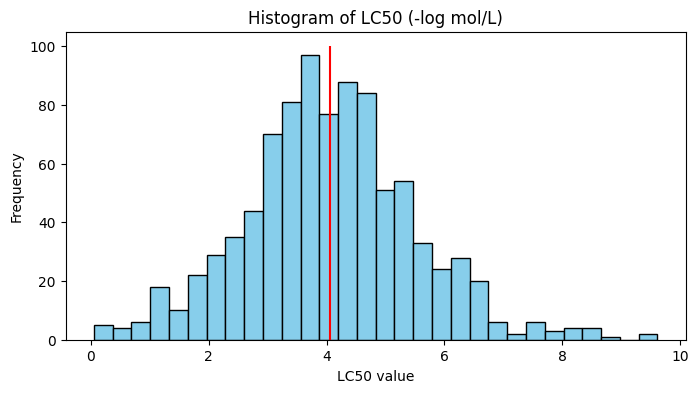

In [37]:
import numpy as np
import matplotlib.pyplot as plt

print(f"shape: {X.shape}")
print(f"mean: {np.mean(y)}")
print(f"standard deviation: {np.std(y)}")
print(f"min: {min(y)}")
print(f"max: {max(y)}")

plt.figure(figsize=(8, 4))
plt.hist(y, bins=30, color='skyblue', edgecolor='black')
plt.vlines([np.mean(y)], ymin=0, ymax=100, color='red')
plt.title("Histogram of LC50 (-log mol/L)")
plt.xlabel("LC50 value")
plt.ylabel("Frequency")
plt.show()

Describe your findings.

#### Interpretations:

- We have 908 data points representing each one chemical compound. Each compound is composed of 6 molecular descriptors (features).
- The target variable (y) spans a wide range (0.053-9.612). We have observations with very low and very high toxicity.
- Most of out data pionts are clustered around the mean (moderate toxicity) and we have a few extreme outliers (low and high toxicity)

### Step 2: Split and preprocess the data

Use the following tools from scikit-learn:
- `train test split` (from `sklearn.model_selection`) to divide the dataset into 70% training, 10% validation, 20% test data.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)

- `StandardScaler` (from `sklearn.preprocessing`) to standardize the features. Fit the scaler only on the training data, then transform the training, validation, and test data.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Step 3: Create PyTorch datasets and loaders

Convert the NumPy arrays to PyTorch tensors and wrap them into `TensorDataset` objects. Create data loaders with a batch size of 64.

In [40]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

### Step 4: Build a regression network

Implement a small feed-forward neural network for regression, for example:
- Three fully connected layers (e.g. 64–32–1 neurons)
- ReLU activation functions between hidden layers

In [41]:
import torch.nn as nn

class FishModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, X):
        return self.net(X)

### Step 5: Training loop
Train the model for up to 200 epochs using `torch.optim.SGD`. Use a similar training loop as in the in-class exercise. However, it should include early stopping functionality:
- Compute and store the training and validation loss. (Think about which loss function to use)
- Keep track of the best validation loss so far.
- Stop training if the validation loss does not improve for a fixed number of epochs (e.g. patience = 10).
- Restore the model weights from the best epoch (You can save the `model.state dict()` during training and load it using `model.load_state_dict(best weights)`)

In [42]:
import torch.optim as optim

model = FishModel(input_dim=X_train.shape[1])
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200
patience = 10
patience_counter = 0
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_weights = None

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

if best_weights is not None:
    model.load_state_dict(best_weights)

Epoch 001 | Train Loss: 12.5550 | Val Loss: 3.4918
Epoch 002 | Train Loss: 2.3935 | Val Loss: 1.1025
Epoch 003 | Train Loss: 1.4171 | Val Loss: 0.8011
Epoch 004 | Train Loss: 1.1880 | Val Loss: 0.7006
Epoch 005 | Train Loss: 1.1000 | Val Loss: 0.6613
Epoch 006 | Train Loss: 1.0571 | Val Loss: 0.6329
Epoch 007 | Train Loss: 1.0111 | Val Loss: 0.6164
Epoch 008 | Train Loss: 0.9810 | Val Loss: 0.5951
Epoch 009 | Train Loss: 0.9628 | Val Loss: 0.5891
Epoch 010 | Train Loss: 0.9530 | Val Loss: 0.5828
Epoch 011 | Train Loss: 0.9235 | Val Loss: 0.5784
Epoch 012 | Train Loss: 0.9047 | Val Loss: 0.5759
Epoch 013 | Train Loss: 0.8904 | Val Loss: 0.5639
Epoch 014 | Train Loss: 0.8781 | Val Loss: 0.5716
Epoch 015 | Train Loss: 0.8697 | Val Loss: 0.5619
Epoch 016 | Train Loss: 0.8609 | Val Loss: 0.5587
Epoch 017 | Train Loss: 0.8472 | Val Loss: 0.5601
Epoch 018 | Train Loss: 0.8370 | Val Loss: 0.5591
Epoch 019 | Train Loss: 0.8364 | Val Loss: 0.5555
Epoch 020 | Train Loss: 0.8235 | Val Loss: 0.5589

### Step 6: Evaluation

After training:
- Evaluate the model on the test set.
- Report MSE, MAE, R^2, and Pearson correlation using `sklearn.metrics`.

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).cpu().numpy().squeeze()

    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    pearson, _ = pearsonr(y_test, preds)

    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"R Squared: {r2:.4f}")
    print(f"Pearson Correlation: {pearson:.4f}")

Test MSE: 0.9815
Test MAE: 0.7100
R Squared: 0.6101
Pearson Correlation: 0.7921


- Create a scatter plot of predicted vs. true LC50 values. Properly annotate the plot.
- Plot the training and validation loss curves over epochs. 

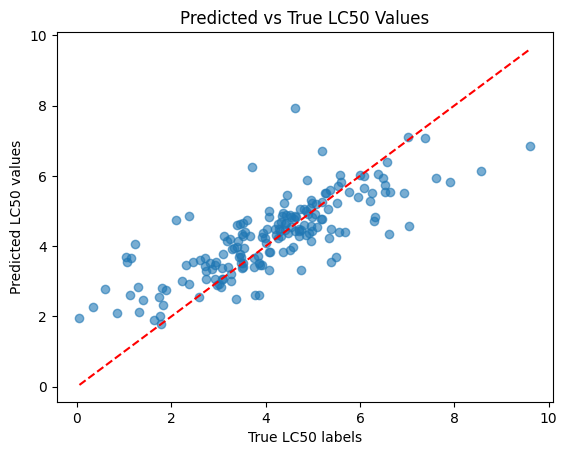

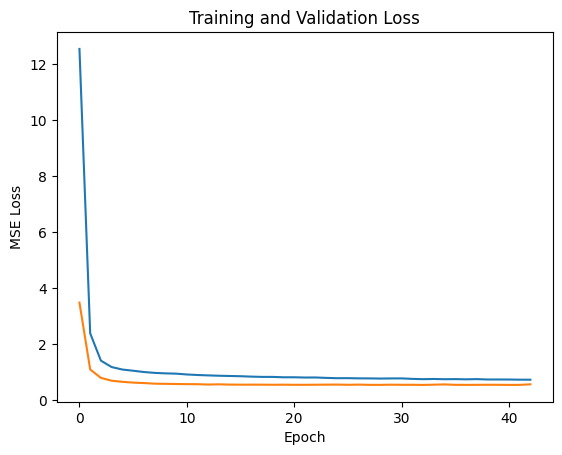

In [44]:
plt.figure()
plt.scatter(y_test, preds, alpha=0.6)
plt.xlabel("True LC50 labels")
plt.ylabel("Predicted LC50 values")
plt.title("Predicted vs True LC50 Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend
plt.title("Training and Validation Loss")
plt.show()

Interpret all results.

#### Test metrics Interpretation:

- MSE: 0.9292 and MAE: 0.6992
    - We acheived a reasonably small error indicating decent accuracy.
- R^2: 0.6308
    - Our model explains 63% of the datas variety, hence the model captures the general distribution but does not do a great job at capturing its variance.
- Pearson Correlation: 0.8024
    - Predictions increase when true values increase.

#### Scatter Plot Interpretations:

The scatter plot shows that the model has a tendancy to slightly overestimate small values and underestimate large values.

#### Training vs. Validation Interpretations:

Training loss is decreasing showing that the model is learning over time. The validation loss also decreasing shows that the model is generalizing well. 

#### Overall Interpretations:

- Our neural network is performing well on the task.
- The model captures the general trends well but likely has room for improvment on the extreme values on both ends of the distribution.

## Exercise 2: Encoding Constraints

Re-use the preprocessing and dataloading from the in-class exercise for the California Housing dataset. Notice that house prices are strictly non-negative. Adapt the neural network to encode this constraint using an activation function after the last layer (eg. `torch.exp`, `Softplus`) and retrain it on the California Housing dataset.

In [45]:
from sklearn.datasets import fetch_california_housing

# changed the way to class is run 
class HouseModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus() # added activation function
        )

    def forward(self, X):
        return self.net(X)
    
california = fetch_california_housing()
X, y = california.data, california.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) 

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = HouseModel(input_dim=X_train.shape[1]) # updated this line to reflec the new class structure

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 10
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        prediction =  model.forward(batch_X)
        loss = loss_fn(prediction, batch_y) 
        optimizer.zero_grad()  
        loss.backward() 
        optimizer.step() 

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
predictions = model.forward(X_test_tensor) 
mse =  loss_fn(predictions, torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)) 
print(f"\nMean Squared Error: {mse:.4f}")

Epoch 2, Loss: 0.5723
Epoch 4, Loss: 0.3787
Epoch 6, Loss: 0.4227
Epoch 8, Loss: 0.2600
Epoch 10, Loss: 0.2881

Mean Squared Error: 0.3607


Report your adaptations to the code (and the relevant code snippet) and the test MSE of your newly trained model.

#### Adaptations to the code:

To enforce the non-negative constraint on house prices we modified the neural network. Specically we added `nn.Softplus()` activation function after the last linear layer, because it only allows positive output values and provides a better gradient descent than ReLU in our test series. The relevant code snippet is commented above. 
```
 def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus() # added activation function
        )
```
#### Interpretation:

The model achieved a MSE if 0.3556 which is slightly better than the one achieved in class 0.4159. 